## Shallow NNs

## 10 neurons in hidden layer

In [6]:
import pandas as pd 
import numpy as np 

In [7]:
data = pd.read_csv('map_data.csv')

In [8]:
# input
X = data[['x', 'y']].values

# output
Y = data['label'].values

In [9]:
# nn libraries
import torch 
import torch.nn as nn
import torch.functional as F 
import torch.optim as optim

In [10]:
# nueral network class
class ShallowNet(nn.Module):
    def __init__(self, input_size = 2, hidden_size = 2, output_size = 2):
        super(ShallowNet, self).__init__()
        self.hidden = nn.Linear(input_size, hidden_size)  #input - hidden layer
        self.bn = nn.BatchNorm1d(hidden_size)
        self.output = nn.Linear(hidden_size, output_size)  #hidden - output layer
        self.relu = nn.ReLU()                              # activation function

    def forward(self, x):
        x = self.hidden(x)
        x = self.bn(x)
        x = self.relu(x)
        x = self.output(x)
        return x
    
model = ShallowNet(input_size = 2, hidden_size = 10, output_size = 2)

loss_fn= nn.CrossEntropyLoss()       # loss
optimizer = optim.Adam(model.parameters(), lr = 0.1) # adjusted lr

epochs = 0
loss = float('inf')
# training loop
while loss > 0.3 and epochs < 500:
    # forward pass
    inputs = torch.tensor(X, dtype=torch.float32)
    labels = torch.tensor(Y, dtype=torch.long)
    outputs = model(inputs)

    # loss
    loss = loss_fn(outputs, labels)
    epochs += 1

    # backward pass and optimization
    optimizer.zero_grad()   # clear old gradients
    loss.backward()         # compute new gradients
    optimizer.step()        # update weights

    if (epochs) % 10 == 0:
        print(f"Epoch [{epochs}]:- Loss: {loss.item():.4f}")


Epoch [10]:- Loss: 0.3551
Epoch [20]:- Loss: 0.3150


c:\Users\Jakkala\anaconda3\envs\ml-env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


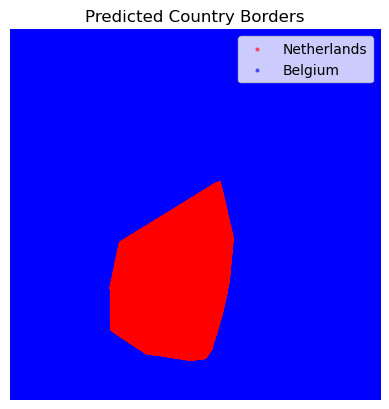

In [11]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

# map image
img = mpimg.imread('Baarle-Nassau_Baarle-Hertog.png')
plt.imshow(img)
plt.axis('off')

inputs = torch.tensor(X, dtype=torch.float32)

# predict
with torch.no_grad():
    outputs = model(inputs)
    preds = torch.argmax(outputs, dim = 1).numpy()

plt.scatter(X[preds == 1, 0], X[preds == 1, 1], c='red', s=4, label='Netherlands', alpha=0.5)
plt.scatter(X[preds == 0, 0], X[preds == 0, 1], c='blue', s=4, label='Belgium', alpha=0.5)
plt.legend()
plt.title("Predicted Country Borders")
plt.show()

In [12]:
# Count and percentage of predictions for each class
total = len(preds)
for label in [0, 1]:
    count = (preds == label).sum()
    print(f"Label {label}: {count} out of {total}")

Label 0: 2036303 out of 2334784
Label 1: 298481 out of 2334784
